# Basics of Statistics

## 1 Introduction

### 1.1 Objective

There are two types of Statistics:

1. Descriptive Statistics
2. Inferential Statistics

![types of statistics](images/types_of_stats.png)
<br />
Image source: https://www.geeksforgeeks.org/maths/statistics/

#### Statistic vs Parameter

$
\begin{array}{|c|c|c|}
\hline
\textbf{ID} & \textbf{Name} & \textbf{Score} \\
\hline
1 & Alice & 95 \\
2 & Bob & 88 \\
3 & Charlie & 92 \\
\hline
\end{array}
$

### 1.2 Setup

#### Import libraries

In [1]:
import numpy as np
from scipy import stats
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.precision", 2)
np.set_printoptions(precision=2, linewidth=100)

#### Import Dataset

In [3]:
df = pd.read_csv("data/weight-height.csv")
df.head(3)

,Gender,Height,Weight
0,Male,73.85,241.89
1,Male,68.78,162.31
2,Male,74.11,212.74


##### Metadata

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 234.5 KB


## 2 Descriptive Statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Height,10000.0,66.37,3.85,54.26,63.51,66.32,69.17,79.00
Weight,10000.0,161.44,32.11,64.70,135.82,161.21,187.17,269.99


### 2.1 Measure of Central Tendency

#### 1 Mean

1. Height: $66.37$
2. Weight: $161.44$

#### 2 Median

#### 3 Mode

In [6]:
df["Gender"].value_counts()

Gender
Male      5000
Female    5000
Name: count, dtype: int64

In [7]:
df["Gender"].mode()

0    Female
1      Male
Name: Gender, dtype: str

### 2.2 Measure of Variance

#### 1 Range

1. Height: $79.00 - 54.26 = 24.74$
2. Weight: $269.99 - 64.70 = 205.29$

#### 2 IQR

1. Quantiles break data into equal parts.
2. Quartiles are a special type of Quantiles that break data into 4 equal parts.

##### Observations

1. Height has shorter range value.
2. Weight has larger range value.

#### 3 Variance

#### 4 Standard Deviation

1. Height: $3.85$
2. Weight: $32.11$

##### Observations

1. Height has smaller standard deviation.
2. Weight has larger standard deviation.

In [8]:
def count_quartiles(arr):
    """
    Function to count elements in each quartile.
    """
    print("Total length:", arr.size)

    mask1 = arr <= np.percentile(arr, 25)
    q1 = arr[mask1]
    print("Size of Q1:", q1.size)

    mask2 = (arr > np.percentile(arr, 25)) & (arr <= np.percentile(arr, 50))
    q2 = arr[mask2]
    print("Size of Q2:", q2.size)

    mask3 = (arr > np.percentile(arr, 50)) & (arr <= np.percentile(arr, 75))
    q3 = arr[mask3]
    print("Size of Q3:", q3.size)

    mask4 = arr > np.percentile(arr, 75)
    q4 = arr[mask4]
    print("Size of Q4:", q4.size)

In [9]:
count_quartiles(df["Height"])

Total length: 10000
Size of Q1: 2500
Size of Q2: 2500
Size of Q3: 2500
Size of Q4: 2500


In [10]:
count_quartiles(df["Weight"])

Total length: 10000
Size of Q1: 2500
Size of Q2: 2500
Size of Q3: 2500
Size of Q4: 2500


## 3 Univariate Analysis

### 3.1 Inter-Quartile Range (IQR)

#### Boxplot

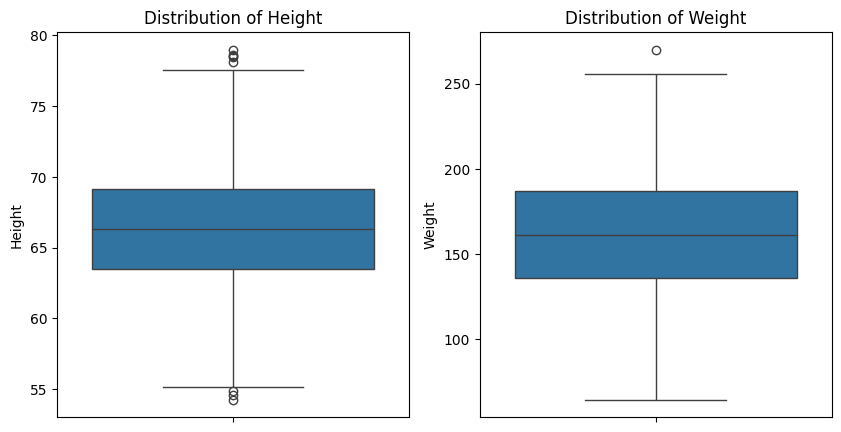

In [11]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, y="Height")
plt.title("Distribution of Height")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y="Weight")
plt.title("Distribution of Weight")

plt.show()

### 3.2 Probability Distribution

#### Histogram

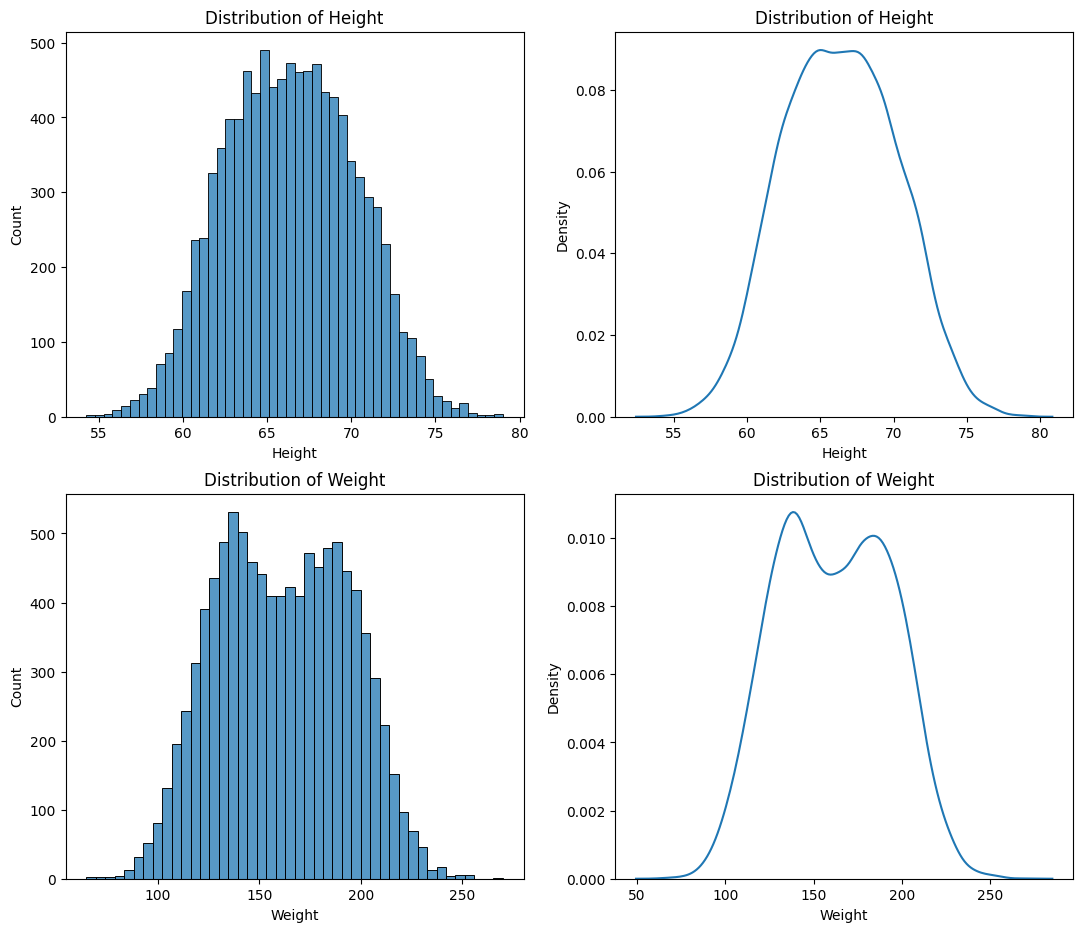

In [25]:
plt.figure(figsize=(13, 11))

plt.subplot(2, 2, 1)
sns.histplot(data=df, x="Height")
plt.title("Distribution of Height")

plt.subplot(2, 2, 2)
sns.kdeplot(data=df, x="Height")
plt.title("Distribution of Height")

plt.subplot(2, 2, 3)
sns.histplot(data=df, x="Weight")
plt.title("Distribution of Weight")

plt.subplot(2, 2, 4)
sns.kdeplot(data=df, x="Weight")
plt.title("Distribution of Weight")

plt.show()

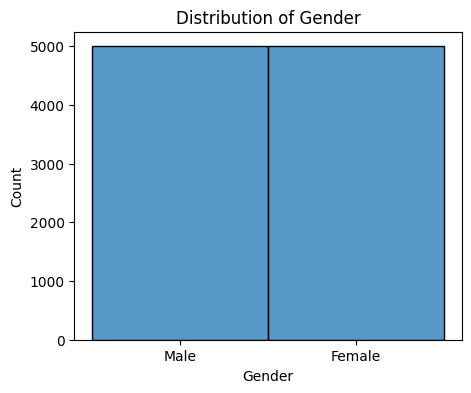

In [13]:
plt.figure(figsize=(5, 4))

sns.histplot(data=df, x="Gender")
plt.title("Distribution of Gender")

plt.show()

## 4 Bivariate Analysis

### 4.1 Inter-Quartile Range (IQR)

#### Boxplot

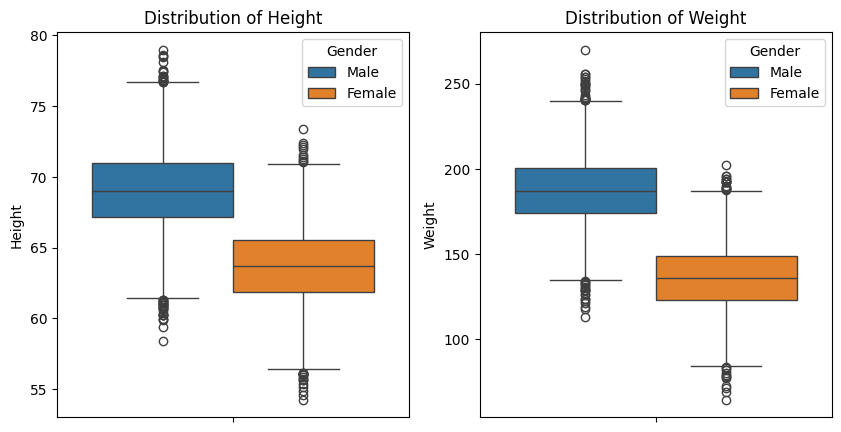

In [14]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, y="Height", hue="Gender")
plt.title("Distribution of Height")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y="Weight", hue="Gender")
plt.title("Distribution of Weight")

plt.show()

### 4.2 Probability Distribution

#### Histogram

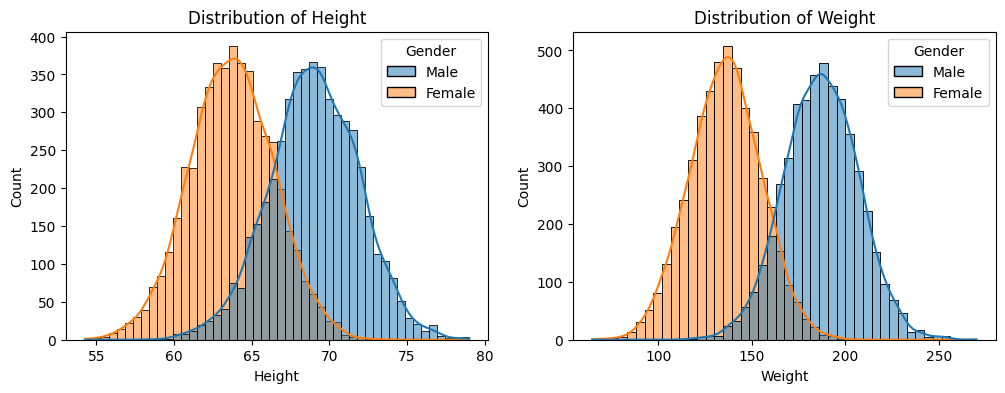

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x="Height", hue="Gender", kde=True)
plt.title("Distribution of Height")

plt.subplot(1, 2, 2)
sns.histplot(data=df, x="Weight", hue="Gender", kde=True)
plt.title("Distribution of Weight")

plt.show()

## 5 Inferential Statistics

### 5.1 Central Limit Theorem

### 5.2 Confidence Interval

### 5.3 Hypothesis Testing